## Signal Amplification by Reversible Exchange (SABRE): Pyridine
## Seven-Spin Model

This notebook extends `sabre_pyridine_threespin.ipynb` by including
all proton spins of one equatorial pyridine ligand together with the
two hydride protons. It therefore provides a more realistic, while
still computationally simple, SABRE simulation for pyridine.

The main features of the model are as follows:

- **Spin system**: two hydride protons and all protons of one bound
  pyridine ligand
- **Simplifications**: chemical exchange and relaxation are neglected,
  and the basis is truncated to fourth spin order
- **Simulation conditions**: the magnetic field is chosen close to the
  level-anticrossing regime, where coherent oscillations between spin
  states are expected
- **Performance**: the example typically runs in about one minute on a
  laptop with an 11th-generation i5 processor

This example is intended as an accessible introduction to seven-spin
SABRE simulations while retaining the essential coherent dynamics of
the spin system.

### Imports

The notebook uses three packages:

- **NumPy** for numerical arrays and data handling
- **Matplotlib** for visualisation of the simulated magnetisations
- **Spinguin** for spin-system construction, Hamiltonian generation,
  propagation, and measurement

In [1]:
# Import the numerical, plotting, and simulation packages.
import numpy as np
import matplotlib.pyplot as plt
import spinguin as sg

### Simulation Parameters

The simulation is performed under the following conditions:

- **Magnetic field (T)**: the global static field in Spinguin is set to
  5.3 mT
- **Time step (s)**: the evolution step is 1 ms
- **Number of time steps**: 1000 points are simulated, corresponding
  to a total evolution time of 1 s

In [2]:
# Define the global experimental conditions.
sg.parameters.magnetic_field = 5.3e-3

# Define the time-discretisation parameters.
time_step = 1e-3
n_steps = 1000

Magnetic field set to: 0.0053 T



### Define the Spin System

To perform the simulation, we first define the spin system and its
working basis.

- **Spin system**: the isotopes of the hydride and pyridine protons are
  specified explicitly
- **Maximum spin order**: the Liouville-space basis is truncated to
  fourth spin order in order to reduce the computational cost
- **Build the basis**: the truncated basis is then constructed using
  the `build()` method

In [3]:
# Initialise the seven-spin SABRE system.
spin_system = sg.SpinSystem(['1H', '1H', '1H', '1H', '1H', '1H', '1H'])

# Restrict the basis to fourth spin order.
spin_system.basis.max_spin_order = 4

# Build the Liouville-space basis.
spin_system.basis.build()

Spin system has been created with the following isotopes:
['1H' '1H' '1H' '1H' '1H' '1H' '1H']

Maximum spin order set to: 4

Basis set has been set. Dimension: 3991.



### Define the NMR Interactions

Only coherent spin dynamics are included in this simplified example.
The spin-system definition therefore requires only the following NMR
parameters:

- **Chemical shifts** in parts per million (ppm)
- **Scalar couplings** in hertz (Hz)

These quantities are assigned directly to the previously created
`SpinSystem` object.

In [4]:
# Define the isotropic chemical shifts of the seven-spin system.
spin_system.chemical_shifts = [
    -22.7, -22.7, 8.34, 8.34, 7.12, 7.12, 7.77,
 ]

# Define the scalar couplings of the seven-spin system.
spin_system.J_couplings = [
    [0, 0, 0, 0, 0, 0, 0],
    [-6.53, 0, 0, 0, 0, 0, 0],
    [0.00, 1.66, 0, 0, 0, 0, 0],
    [1.40, 0.00, -0.06, 0, 0, 0, 0],
    [-0.09, 0.35, 6.03, 0.14, 0, 0, 0],
    [0.38, -0.13, 0.09, 5.93, 0.06, 0, 0],
    [0.01, 0.03, 1.12, -0.02, 7.75, -0.01, 0],
]

Assigned the following chemical shifts:
[-22.7  -22.7    8.34   8.34   7.12   7.12   7.77]

Assigned the following J-couplings:
[[ 0.    0.    0.    0.    0.    0.    0.  ]
 [-6.53  0.    0.    0.    0.    0.    0.  ]
 [ 0.    1.66  0.    0.    0.    0.    0.  ]
 [ 1.4   0.   -0.06  0.    0.    0.    0.  ]
 [-0.09  0.35  6.03  0.14  0.    0.    0.  ]
 [ 0.38 -0.13  0.09  5.93  0.06  0.    0.  ]
 [ 0.01  0.03  1.12 -0.02  7.75 -0.01  0.  ]]



### Calculate the Hamiltonian, Liouvillian, and Propagator

The coherent generator of motion is assembled in three steps:

- **Hamiltonian**: constructed from the spin-system definition
- **Liouvillian**: built using the Spinguin convention
  $L = -iH - R + K$
- **Time propagator**: evaluated from the Liouvillian for one time step

Because this example contains only coherent dynamics, neither a
relaxation superoperator nor an exchange contribution is supplied.

In [5]:
# Calculate the Hamiltonian of the spin system.
hamiltonian = sg.hamiltonian(spin_system)

# Assemble the Liouvillian for coherent time evolution.
liouvillian = sg.liouvillian(hamiltonian)

# Calculate the propagator for one simulation step.
propagator = sg.propagator(liouvillian, time_step)

Constructing the Hamiltonian...
Hamiltonian constructed in 0.2266 seconds.

Constructing the time propagator...
Computing the matrix exponential using Taylor series with scaling and squaring...
Taylor series...
Term 1...
Term 2...
Term 3...
Term 4...
Term 5...
Term 6...
Term 7...
Term 8...
Term 9...
Term 10...
Term 11...
Term 12...
Term 13...
Term 14...
Term 15...
Term 16...
Term 17...
Term 18...
Taylor series converged.
Matrix squaring...
Step 1...
Step 2...
Step 3...
Step 4...
Step 5...
Step 6...
Step 7...
Step 8...
Step 9...
Step 10...
Step 11...
Step 12...
Step 13...
Matrix exponential computed.
Propagator density: 0.1724
Time propagator constructed in 9.0921 seconds.



### Assign the Initial State

The initial state is chosen so that the two hydride protons form a
singlet. This supplies the non-equilibrium spin order that is later
transferred through the coherent dynamics of the coupled seven-spin
system.

In [6]:
# Initialise the density operator as a hydride singlet state.
rho = sg.singlet_state(spin_system, 0, 1)

### Allocate Storage for the Magnetisations

The magnetisation of each spin is stored throughout the simulation.
The array therefore contains one complex-valued time trace for each
spin over all simulated time steps.

In [7]:
# Allocate storage for the magnetisations of all spins.
magnetizations = np.empty((spin_system.nspins, n_steps), dtype=complex)

### Perform the Time Evolution

The system is evolved by repeating the following steps at each time
point:

- measure the instantaneous magnetisation of every spin
- store the measured values for later analysis
- propagate the density operator by one time step

In [8]:
# Evolve the spin system for the specified number of time steps.
for step in range(n_steps):

    # Measure the longitudinal magnetisation of each spin.
    for spin in range(spin_system.nspins):
        magnetizations[spin, step] = sg.measure(
            spin_system,
            rho,
            f"I(z, {spin})",
        )

    # Propagate the density operator by one time step.
    rho = propagator @ rho

### Plot the Results

Finally, the simulated magnetisations are plotted as a function of
time. The signals show coherent oscillations that are qualitatively
similar to those in the three-spin example. Because the seven-spin
system is more complex, however, the dynamics are distributed over a
larger number of coupled states and the transfer of polarisation to
the pyridine protons is less efficient than in the idealised smaller
model.

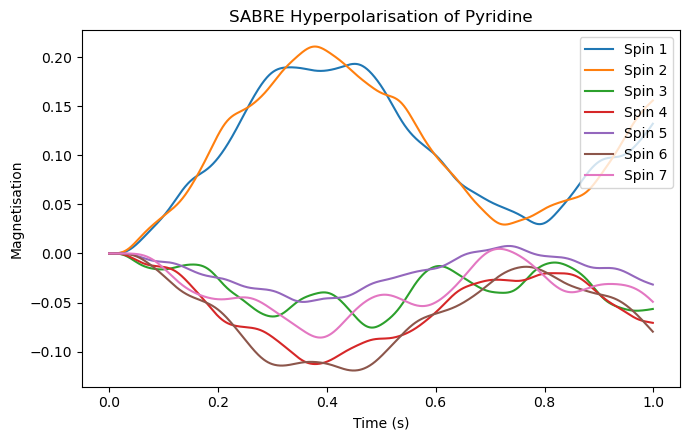

In [9]:
# Construct the time axis of the simulation.
time = sg.time_axis(n_steps, time_step)

# Create a figure for the simulated magnetisation curves.
fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot the real part of the magnetisation for each spin.
for spin in range(spin_system.nspins):
    ax.plot(
        time,
        np.real(magnetizations[spin]),
        label=f"Spin {spin + 1}",
    )

# Add a legend that identifies each spin.
ax.legend(loc="upper right")

# Label the axes and add a descriptive title.
ax.set_xlabel("Time (s)")
ax.set_ylabel("Magnetisation")
ax.set_title("SABRE Hyperpolarisation of Pyridine")

# Adjust the layout and display the figure.
fig.tight_layout()
plt.show()

# Close the figure before any later plots are created.
plt.close(fig)